# Resonance vs. Integrator Dynamics in the AMAT Model

This notebook investigates and validates the characteristics of Post-Synaptic Currents (PSCs) in resonators versus integrators using the AMAT NESTML model. 

### Difference between integrator vs. resonator PSC behaviour? 
- Integrator Behaviour (All-Pass): Acts like a leaky bucket. It accumulates (sums up) all incoming inputs over time, regardless of their timing. It fires a spike when the total input volume exceeds the threshold. It acts as a low-pass filter, favoring high-frequency bursts or closely packed inputs.
- Resonator Behaviour (Band-Pass): Acts like a swing. It is highly sensitive to the specific **timing** and **frequency** of inputs. It prefers a specific inter-pulse interval ($\Delta$). If a second pulse arrives at the peak of the internal oscillation caused by the first pulse, the system "resonates" and triggers a spike. If the timing is off, the inputs cancel out.

These firing behaviours are depicted in the figure below

<img src="images/integrator_resonator.png" width="1050" height="600">

In [1]:
import nest
import pynestml
import sys
from pathlib import Path
from dataclasses import dataclass, replace 
from typing import Literal, Mapping, Sequence
import numpy as np
import matplotlib.pyplot as plt
import importlib
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



# Build and validate the NESTML AMAT neuronal model 

In [2]:
def build_nestml_model(
    source_path: Path,
    module_name: str,) -> tuple[str, str]:
    
    if not source_path.exists():
        raise FileNotFoundError(f"NESTML source not found: {source_path}")

    generated_module, generated_model = NESTCodeGeneratorUtils.generate_code_for( # nest call to compile nestml c++ script 
        str(source_path),
        module_name=module_name,
        logging_level="INFO",)

    try:
        nest.Install(generated_module)
        print(f"Successfully installed module: '{generated_module}'")
    except nest.kernel.NESTError:
        print(f"Module '{generated_module}' is already installed. Skipping installation step.")

    # Verify the MODEL name is loaded and recognized by the NEST engine
    if generated_model not in nest.Models():
        raise RuntimeError(
            f"Generation completed, but model '{generated_model}' is missing from nest.Models()."
        )
    
    # return module, name 
    return generated_module, generated_model

# defining global variables 
nest_model = "amat2_psc_exp"
nestml_source = Path("./neurons_nestml/amat_neuron.nestml")
nestml_module = "nestml_amat_module"
resolution_ms = 0.1

# calling build function
module_name, nestml_model = build_nestml_model(
    nestml_source,
    nestml_module,
)

print("Loaded module:", module_name)
print("Generated model:", nestml_model)
print("NESTML recordables:", nest.GetDefaults(nestml_model)["recordables"])

[1,GLOBAL, INFO]: List of files that will be processed:
[2,GLOBAL, INFO]: /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/neurons_nestml/amat_neuron.nestml
[3,GLOBAL, INFO]: Target platform code will be generated in directory: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target"
[4,GLOBAL, INFO]: Target platform code will be installed in directory: "/var/folders/jk/36jftn6s3yz6ks1zj2zdlry40000gn/T/nestml_target_y_5gsl3d"

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0-post0.dev14
 Built  : Jul 16 2026 16:13:29

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[5,GLOBAL, INFO]: The NEST Simulator version was automatically detected as: main
[6,GLOBAL, INFO]: Given template root path is not an absolute path. Creating the absolute path with default templates direc

INFO:root:Analysing input:
INFO:root:{
    "dynamics": [
        {
            "expression": "V_th_alpha_1' = (-V_th_alpha_1) / tau_1",
            "initial_values": {
                "V_th_alpha_1": "0"
            }
        },
        {
            "expression": "V_th_alpha_2' = (-V_th_alpha_2) / tau_2",
            "initial_values": {
                "V_th_alpha_2": "0"
            }
        },
        {
            "expression": "V_m' = ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_m": "E_L"
            }
        },
        {
            "expression": "V_th_v_aux' = (-V_th_v_aux) / tau_v + beta * ((-(V_m - E_L)) / tau_m + ((((unit_psc * I_kernel_exc__X__exc_spikes)) + (((-unit_psc) * I_kernel_inh__X__inh_spikes))) + I_e + I_stim) / C_m)",
            "initial_values": {
                "V_th_v_aux": "0 / 1.0"
            }
        },


[11,GLOBAL, INFO]: Starting code generation for model "amat_neuron_nestml"
[12,amat_neuron_nestml, INFO, [124:0;238:0]]: Starts processing of the model "amat_neuron_nestml"
[13,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.cpp
[14,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/amat_neuron_nestml.h
[15,amat_neuron_nestml, INFO, [124:0;238:0]]: Successfully generated code for the model: "amat_neuron_nestml" in: "/Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target" !
[16,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/CMakeLists.txt
[17,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.h
[18,GLOBAL, INFO]: Rendering template /Users/angusgray/Desktop/JSC/github/jsc_nestml_amat/juypter/target/nestml_amat_module.cpp
[19,GLOBAL, IN

/Users/angusgray/Desktop/JSC/nest-simulator/mamba/lib/python3.12/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
Models is deprecated and will be removed in a future version of NEST.
Please use nest.node_models or nest.synapse_models instead!


## NEST NESTML parameter config

Building dataclass configs for NESTML and NEST models, with `Frozen=True` and `Literal[]` so the data and variables cannot be influenced and affected in downstream simulations

For instance, mismatch in NESTML, NEST:
- NESTML expects that offset directly: `omega = 5 mV`.
- Native NEST exposes `omega` as the **absolute threshold** in its status dictionary, so the equivalent value is `E_L + 5 mV = -65 mV`.


In [3]:
from dataclasses import dataclass
from typing import Literal, Mapping

# restricts so only modeltype can be the following 
ModelType = Literal["nest", "nestml"]

@dataclass(frozen=True) # pass AMATConfig into both nestml and nest configs, ensures params are kept the same 
class AMATConfig:
    
    pulse_times_ms: tuple[float, ...] = (150.0, 170.0, 300.0, 360.0)
    pulse_amplitude_pa: float = 1000.0
    pulse_width_ms: float = 1.0
    simulation_time_ms: float = 500.0

    tau_m_ms: float = 10.0
    gamma: float = 1.5
    B: float = 4.0

    E_L_mv: float = -70.0
    resting_threshold_mv: float = -65.0

    alpha_1_mv: float = 5.0
    alpha_2_mv: float = 0.0
    tau_1_ms: float = 10.0
    tau_2_ms: float = 200.0
    
    @property # turns it into a read-only attribute 
    def tau_v_ms(self) -> float:
        """Voltage-dependent threshold timescale."""
        if self.gamma <= 0:
            raise ValueError("gamma must be greater than zero because tau_v = gamma * tau_m.")
        return self.gamma * self.tau_m_ms

    @property # Fixed: removed the extra leading space
    def beta_per_ms(self) -> float: # Fixed: removed the extra leading space
        """Convert dimensionless B to the model parameter beta."""
        return self.B / self.tau_m_ms

@dataclass # writes boilerplate code for the classes e.g., init, rep, eq
class SimulationResult:
    model_name: str
    model_type: ModelType
    events: Mapping
    spikes: Mapping
    parameters: dict[str, float]


# Helper functions 

In [4]:
def install_generated_module(module_name: str) -> None:
    """Install the generated module if it is not already loaded.""" # ensure the generated module is in the kernel 
    try:
        nest.Install(module_name)
    except Exception as exc:
        message = str(exc).lower()
        if "loaded already" not in message and "already loaded" not in message: # should be used for nest, nestml will be built and already present. 
            raise

def create_step_current(
    pulse_times_ms: Sequence[float],
    pulse_width_ms: float,
    pulse_amplitude_pa: float,
):
    """Create a rectangular pulse train using one step-current generator."""
    amplitude_times: list[float] = []
    amplitude_values: list[float] = []

    for onset in pulse_times_ms:
        amplitude_times.extend([onset, onset + pulse_width_ms])
        amplitude_values.extend([pulse_amplitude_pa, 0.0])

    return nest.Create(
        "step_current_generator",  # input config for injecting I(e) into the neuron 
        params={
            "amplitude_times": amplitude_times,    # pulse params are stored in the public API  
            "amplitude_values": amplitude_values,    
        },
    )


def identify_model_type(model_name: str) -> ModelType: 
    # Using your global variables 'nest_model' and 'nestml_model' directly
    if model_name == nest_model:
        return "nest"   
    if model_name == nestml_model:
        return "nestml"
    raise ValueError(f"Unsupported AMAT model: {model_name}")


def build_model_parameters(
    model_name: str,
    model_type: ModelType,
    config: AMATConfig,
) -> dict[str, float]:
    """Translate the shared configuration to each model's public API."""
    defaults = nest.GetDefaults(model_name)
    tau_m = float(defaults.get("tau_m", config.tau_m_ms))

    parameters = {
        "tau_m": tau_m,
        "tau_v": config.gamma * tau_m,
        "beta": config.B / tau_m,
        "alpha_1": config.alpha_1_mv,
        "alpha_2": config.alpha_2_mv,
        "tau_1": config.tau_1_ms,
        "tau_2": config.tau_2_ms,
    }

    # The native model normally exposes omega as an absolute voltage.
    # The supplied NESTML equation uses E_L + omega, so it expects an offset.
    if model_type == "nest":
        parameters["omega"] = config.resting_threshold_mv
    else:
        parameters["omega"] = (
            config.resting_threshold_mv - config.E_L_mv
        )

    # Only pass parameters actually supported by the selected model.
    return {
        key: value
        for key, value in parameters.items()
        if key in defaults
    }

# available and selected recordables may have different names dep on the nestml/nest config soruce of mismatch errors 
def select_recordables(model_name: str, requested: Sequence[str]) -> list[str]:
    """Keep only quantities actually exposed by the selected model."""
    
    available = set(nest.GetDefaults(model_name)["recordables"])   # collect the recordables available at the nest terminal
    selected = [name for name in requested if name in available]

    if "V_m" not in selected:
        raise RuntimeError(f"{model_name} does not expose V_m.")

    return selected

In [5]:
REQUESTED_RECORDABLES = (
    "V_m",
    "V_th",
    "V_th_alpha_1",
    "V_th_alpha_2",
    "V_th_v",
    "V_th_v_aux",
    "I_syn_ex",
    "I_syn_in",
    "I_syn",
)


def run_amat_model(
    model_name: str,
    config: AMATConfig,
    *,
    verbose: bool = False,
) -> SimulationResult:
    """Run either the native NEST or generated NESTML AMAT model."""
    nest.ResetKernel()
    nest.SetKernelStatus({"resolution": resolution_ms})
    nest.set_verbosity("M_ERROR")

    model_type = identify_model_type(model_name)

    if model_type == "nestml":
        install_generated_module(module_name)

    if model_name not in nest.Models():
        raise RuntimeError(f"Model is not loaded: {model_name}")

    parameters = build_model_parameters(model_name, model_type, config)
    neuron = nest.Create(model_name, params=parameters)

    current = create_step_current(config.pulse_times_ms,
                                  config.pulse_width_ms,
                                  config.pulse_amplitude_pa)

    nest.Connect(current, neuron)

    spike_recorder = nest.Create("spike_recorder")
    nest.Connect(neuron, spike_recorder)

    recordables = select_recordables(
        model_name,
        REQUESTED_RECORDABLES,
    )
    multimeter = nest.Create(
        "multimeter",
        params={
            "interval": resolution_ms,
            "record_from": recordables,
        },
    )
    nest.Connect(multimeter, neuron)

    nest.Simulate(config.simulation_time_ms)

    events = multimeter.get("events")
    spikes = spike_recorder.get("events")

    if verbose:
        print(f"{model_name}: parameters={parameters}")
        print("recordables:", recordables)
        print("spikes:", np.asarray(spikes["times"]))

    return SimulationResult(
        model_name=model_name,
        model_type=model_type,
        events=events,
        spikes=spikes,
        parameters={
            **parameters,
            "gamma": config.gamma,
            "B": config.B,
        },
    )


# Mismatch in voltage recordings NEST NESTML

The native model records `V_th` as an absolute voltage. The NESTML model now records the same absolute threshold directly. Native NEST records `I_syn_ex` and `I_syn_in` separately, so total `I_syn` is their sum. Discrete differences that affect the comparision in the output 

In [6]:
def reconstruct_input_current(
    times_ms: np.ndarray,
    config: AMATConfig,
) -> np.ndarray:
    """Reconstruct the commanded current for plotting."""
    current = np.zeros_like(times_ms, dtype=float)

    for onset in config.pulse_times_ms:
        active = (
            (times_ms >= onset)
            & (times_ms < onset + config.pulse_width_ms)
        )
        current[active] = config.pulse_amplitude_pa

    return current


def reconstruct_spike_history(
    times_ms: np.ndarray,
    spike_times_ms: np.ndarray,
    alpha_mv: float,
    tau_ms: float,
) -> np.ndarray:
    """Reconstruct a hidden exponential spike-history component."""
    component = np.zeros_like(times_ms, dtype=float)

    for spike_time in spike_times_ms:
        after_spike = times_ms >= spike_time
        component[after_spike] += alpha_mv * np.exp(
            -(times_ms[after_spike] - spike_time) / tau_ms
        )

    return component


def standardise_result(
    result: SimulationResult,
    config: AMATConfig,
) -> dict[str, np.ndarray]:
    """Return identical trace names for native NEST and NESTML."""
    events = result.events
    times = np.asarray(events["times"], dtype=float)
    V_m = np.asarray(events["V_m"], dtype=float)
    spikes = np.asarray(result.spikes["times"], dtype=float)
    zeros = np.zeros_like(V_m)

    alpha_1 = np.asarray(
        events.get(
            "V_th_alpha_1",
            reconstruct_spike_history(
                times, spikes, config.alpha_1_mv, config.tau_1_ms
            ),
        )
    )
    alpha_2 = np.asarray(
        events.get(
            "V_th_alpha_2",
            reconstruct_spike_history(
                times, spikes, config.alpha_2_mv, config.tau_2_ms
            ),
        )
    )
    theta_v = np.asarray(events.get("V_th_v", zeros))

    if "V_th" in events:
        # Treat a clearly negative V_th trace as an absolute threshold.
        raw_theta = np.asarray(events["V_th"], dtype=float)
        theta = (
            raw_theta
            if np.nanmedian(raw_theta) < 0
            else config.E_L_mv + raw_theta
        )
    else:
        theta = (
            config.resting_threshold_mv
            + alpha_1
            + alpha_2
            + theta_v
        )

    return {
        "times": times,
        "input_current": reconstruct_input_current(times, config),
        "V_m": V_m,
        "theta": theta,
        "distance": V_m - theta,
        "V_th_alpha_1": alpha_1,
        "V_th_alpha_2": alpha_2,
        "V_th_v": theta_v,
        "spike_times": spikes,
    }


# ISI Delta Sweep Experiments 

Each simulation contains two identical current pulses. The first pulse occurs at
200 ms and the second at `200 + delta` ms. We measure the largest post-pulse
distance `V_m - theta`, whether a spike occurred, and the number of spikes.

The same sweep function is used for native NEST and NESTML, which prevents the
two implementations from silently using different timing or analysis rules.

In [7]:
def run_delta(
    model_name: str,
    base_config: AMATConfig,
    delta_ms: float,
    *,
    first_pulse_ms: float = 200.0,
    response_window_ms: float = 60.0,
):
    """Run one two-pulse experiment at a specified inter-pulse interval."""
    second_pulse_ms = first_pulse_ms + float(delta_ms)

    config = replace(
        base_config,
        pulse_times_ms=(first_pulse_ms, second_pulse_ms),
        simulation_time_ms=second_pulse_ms + response_window_ms + 20.0,
    )

    result = run_amat_model(
        model_name=model_name,
        config=config,
        verbose=False,
    )
    traces = standardise_result(result, config)

    # Start one integration step after the pulse onset. This avoids measuring
    # the pre-pulse sample at exactly second_pulse_ms.
    window = (
        (traces["times"] > second_pulse_ms)
        & (traces["times"] <= second_pulse_ms + response_window_ms)
    )
    if not np.any(window):
        raise RuntimeError("The post-second-pulse response window is empty.")

    spike_window = (
        (traces["spike_times"] >= second_pulse_ms)
        & (traces["spike_times"] <= second_pulse_ms + response_window_ms)
    )

    return {
        "delta_ms": float(delta_ms),
        "max_distance_mv": float(np.max(traces["distance"][window])),
        "peak_voltage_mv": float(np.max(traces["V_m"][window])),
        "spike_after_second": bool(np.any(spike_window)),
        "n_spikes_after_second": int(np.sum(spike_window)),
        "config": config,
        "traces": traces,
    }


def sweep_delta(
    label: str,
    model_name: str,
    base_config: AMATConfig,
    deltas_ms: Sequence[float],
):
    """Run a complete delta sweep and store plotting-ready arrays."""
    runs = [
        run_delta(
            model_name=model_name,
            base_config=base_config,
            delta_ms=delta,
        )
        for delta in deltas_ms
    ]

    return {
        "label": label,
        "model_name": model_name,
        "deltas_ms": np.asarray(deltas_ms, dtype=float),
        "max_distance_mv": np.asarray(
            [run["max_distance_mv"] for run in runs]
        ),
        "peak_voltage_mv": np.asarray(
            [run["peak_voltage_mv"] for run in runs]
        ),
        "spike_after_second": np.asarray(
            [run["spike_after_second"] for run in runs],
            dtype=bool,
        ),
        "n_spikes_after_second": np.asarray(
            [run["n_spikes_after_second"] for run in runs],
            dtype=int,
        ),
        "runs": runs,
        "config": base_config,
    }


# Main comparison: integrator control and resonator condition

`B=0` disables the voltage-dependent threshold contribution and acts as the
MAT-like control. `B=4` activates that contribution. Both conditions are run
through native NEST and NESTML so implementation agreement can be inspected.


In [15]:
deltas_ms = np.arange(2.0, 150.0, 2.0)

# B=0 removes the voltage-dependent threshold contribution.
integrator_config = AMATConfig(
    pulse_amplitude_pa=750.0,
    pulse_width_ms=1.0,
    gamma=1.5,
    B=0.0,
    alpha_1_mv=5.0,
    alpha_2_mv=0.0,
)

# Positive B activates the voltage-dependent threshold term.
resonator_config = replace(
    integrator_config,
    gamma=1.5,
    B=4.0,
)

# Run both parameter conditions in both implementations.
integrator_nest_sweep = sweep_delta(
    "Native NEST — B=0",
    nest_model,
    integrator_config,
    deltas_ms,
)
integrator_nestml_sweep = sweep_delta(
    "NESTML — B=0",
    nestml_model,
    integrator_config,
    deltas_ms,
)
resonator_nest_sweep = sweep_delta(
    r"Native NEST — B=4, $\gamma$=1.5",
    nest_model,
    resonator_config,
    deltas_ms,
)
resonator_nestml_sweep = sweep_delta(
    r"NESTML — B=4, $\gamma$=1.5",
    nestml_model,
    resonator_config,
    deltas_ms,
)

all_main_sweeps = [
    integrator_nest_sweep,
    integrator_nestml_sweep,
    resonator_nest_sweep,
    resonator_nestml_sweep,
]


# Plot the complete comparison

Binary spike occurrence is drawn with a step plot rather than an interpolated
line. A third panel shows spike count, which distinguishes one spike from a
burst and makes the result easier to interpret.

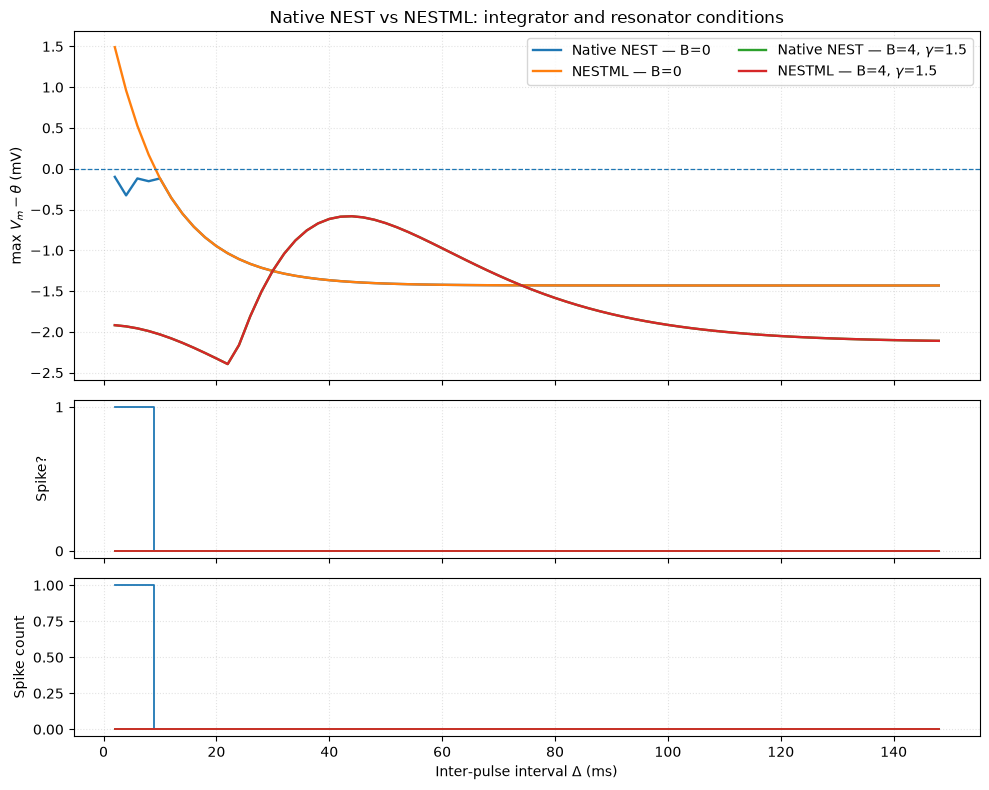

[{'label': 'Native NEST — B=0',
  'model_name': 'amat2_psc_exp',
  'deltas_ms': array([  2.,   4.,   6.,   8.,  10.,  12.,  14.,  16.,  18.,  20.,  22.,
          24.,  26.,  28.,  30.,  32.,  34.,  36.,  38.,  40.,  42.,  44.,
          46.,  48.,  50.,  52.,  54.,  56.,  58.,  60.,  62.,  64.,  66.,
          68.,  70.,  72.,  74.,  76.,  78.,  80.,  82.,  84.,  86.,  88.,
          90.,  92.,  94.,  96.,  98., 100., 102., 104., 106., 108., 110.,
         112., 114., 116., 118., 120., 122., 124., 126., 128., 130., 132.,
         134., 136., 138., 140., 142., 144., 146., 148.]),
  'max_distance_mv': array([-0.09958367, -0.32644449, -0.11881146, -0.15283035, -0.11858977,
         -0.35656247, -0.55139803, -0.7109159 , -0.84151809, -0.94844611,
         -1.03599138, -1.10766738, -1.16635072, -1.21439658, -1.2537332 ,
         -1.2859393 , -1.31230743, -1.33389583, -1.35157091, -1.36604205,
         -1.37789001, -1.3875903 , -1.39553223, -1.40203453, -1.40735816,
         -1.41171678, -1

In [17]:
def plot_delta_sweeps(
    sweeps: Sequence[Mapping],
    *,
    title: str = "Pulse-pair delta sweep",
):
    """Plot threshold distance and spike output on aligned axes."""
    fig, axes = plt.subplots(
        3,
        1,
        figsize=(10, 8),
        sharex=True,
        gridspec_kw={"height_ratios": [2.2, 1.0, 1.0]},
    )

    for sweep in sweeps:
        delta = sweep["deltas_ms"]
        label = sweep["label"]

        axes[0].plot(
            delta,
            sweep["max_distance_mv"],
            linewidth=1.7,
            label=label,
        )
        axes[1].step(
            delta,
            sweep["spike_after_second"].astype(int),
            where="mid",
            linewidth=1.3,
            label=label,
        )
        axes[2].step(
            delta,
            sweep["n_spikes_after_second"],
            where="mid",
            linewidth=1.3,
            label=label,
        )

    axes[0].axhline(0.0, linestyle="--", linewidth=0.9)
    axes[0].set_ylabel(r"max $V_m-\theta$ (mV)")
    axes[0].set_title(title)
    axes[0].legend(ncol=2)

    axes[1].set_ylabel("Spike?")
    axes[1].set_yticks([0, 1])

    axes[2].set_ylabel("Spike count")
    axes[2].set_xlabel(r"Inter-pulse interval $\Delta$ (ms)")
    axes[2].set_ylim(bottom=-0.05)

    for axis in axes:
        axis.grid(True, linestyle=":", alpha=0.35)

    fig.tight_layout()
    plt.show()
    return fig, axes


plot_delta_sweeps(
    all_main_sweeps,
    title="Native NEST vs NESTML: integrator and resonator conditions",
)

all_main_sweeps
# native nest = b4, gamma1.5 where is it? need  ot finetune this .

# Gamma-timescale sweep

Here `B` is held fixed while `gamma` changes. This is important because the two
parameters have different meanings: `gamma` changes `tau_v`, whereas `B`
changes `beta`. A value of `gamma=0` is excluded because it would imply an
invalid zero time constant.

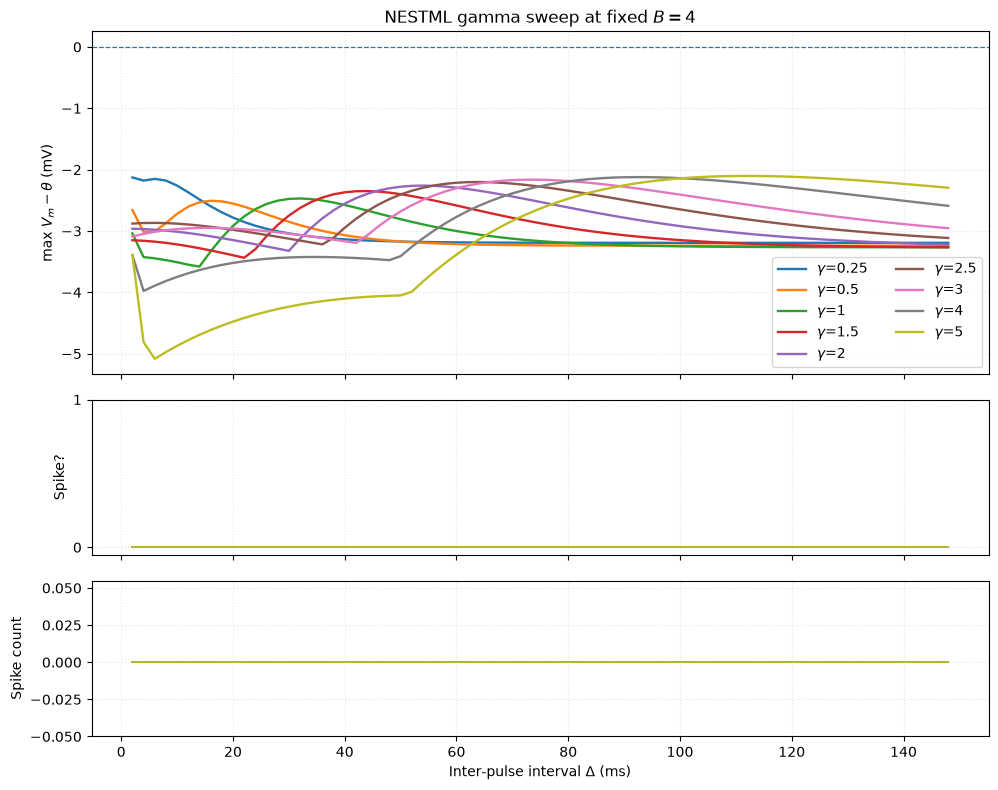

(<Figure size 1000x800 with 3 Axes>,
 array([<Axes: title={'center': 'NESTML gamma sweep at fixed $B=4$'}, ylabel='max $V_m-\\theta$ (mV)'>,
        <Axes: ylabel='Spike?'>,
        <Axes: xlabel='Inter-pulse interval $\\Delta$ (ms)', ylabel='Spike count'>],
       dtype=object))

In [10]:
# Gamma controls the timescale tau_v = gamma * tau_m.
# B controls the strength beta = B / tau_m.
gamma_values = [0.25, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 4.0, 5.0]

gamma_nestml_sweeps = []
for gamma_value in gamma_values:
    gamma_config = replace(
        resonator_config,
        gamma=gamma_value,
        B=4.0,
    )
    gamma_nestml_sweeps.append(
        sweep_delta(
            label=rf"$\gamma$={gamma_value:g}",
            model_name=nestml_model,
            base_config=gamma_config,
            deltas_ms=deltas_ms,
        )
    )

plot_delta_sweeps(
    gamma_nestml_sweeps,
    title=r"NESTML gamma sweep at fixed $B=4$",
)
